In [43]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [44]:
#Reading the data for training the model
df=pd.read_csv("/content/FactTable.csv")

In [45]:
from enum import unique
#Performing aggregration and grouping keeping each player details unique
aggregration_rules={
    "player_name":"first",
    "player_positions": lambda x: ', '.join(x.unique()),
    "club_name": lambda y: ', '.join(y.dropna().astype(str).unique()),
    "wage_eur":"last",
    "age":"last",
    "height_cm":"last",
    "weight_kg":"last",
    "weak_foot":"last",
    "skill_moves":"last",
    "overall":"last",
    "potential":"last",
    "value_eur":"last",
    "pace":"last",
    "shooting":"last",
    "passing":"last",
    "dribbling":"last",
    "defending":"last",
    "physic":"last",
    "attacking_crossing":"last",
    "attacking_finishing":"last",
    "attacking_heading_accuracy":"last",
    "attacking_short_passing":"last",
    "attacking_volleys":"last",
    "skill_dribbling":"last",
    "skill_curve":"last",
    "skill_fk_accuracy":"last",
    "skill_long_passing":"last",
    "skill_ball_control":"last",
    "movement_acceleration":"last",
    "movement_sprint_speed":"last",
    "movement_agility":"last",
    "movement_reactions":"last",
    "movement_balance":"last",
    "power_shot_power":"last",
    "power_jumping":"last",
    "power_stamina":"last",
    "power_strength":"last",
    "power_long_shots":"last",
    "mentality_aggression":"last",
    "mentality_interceptions":"last",
    "mentality_positioning":"last",
    "mentality_vision":"last",
    "mentality_penalties":"last",
    "mentality_composure":"last",
    "defending_marking_awareness":"last",
    "defending_standing_tackle":"last",
    "defending_sliding_tackle":"last",
    "goalkeeping_diving":"last",
    "goalkeeping_handling":"last",
    "goalkeeping_kicking":"last",
    "goalkeeping_positioning":"last",
    "goalkeeping_reflexes":"last",
    "goalkeeping_speed":"last",
    "dob":"first",
    "nationality_name":"first",
    "preferred_foot":"first",
    "work_rate":"first",
    "body_type":"first",
    "real_face":"first",
    "release_clause_eur":"last",
    "international_reputation":"last",
    "weak_foot":"last",
    "skill_moves":"last",
    "work_rate":"first",
    "body_type":"first",
    "real_face":"first",
    "release_clause_eur":"last",
    "league_name":"first",

}

df=df.groupby("player_id").agg(aggregration_rules).reset_index()

In [46]:
#For feature selection add all continuous colums that define a players trait.
feature_col=["overall","potential","value_eur","wage_eur","age","height_cm","weight_kg","weak_foot","skill_moves","pace","shooting","passing","dribbling",
             "defending","physic","attacking_crossing","attacking_finishing","attacking_heading_accuracy","attacking_short_passing","attacking_volleys",
             "skill_dribbling","skill_curve","skill_fk_accuracy","skill_long_passing","skill_ball_control","movement_acceleration","movement_sprint_speed",
             "movement_agility","movement_reactions","movement_balance","power_shot_power","power_jumping","power_stamina","power_strength","power_long_shots",
             "mentality_aggression","mentality_interceptions","mentality_positioning","mentality_vision","mentality_penalties","mentality_composure",
             "defending_marking_awareness","defending_standing_tackle","defending_sliding_tackle","goalkeeping_diving","goalkeeping_handling","goalkeeping_kicking",
             "goalkeeping_positioning","goalkeeping_reflexes","goalkeeping_speed"]

In [47]:
df_features=df[feature_col].copy()

In [48]:
#Fiiling the missing values with its mean
df_features.fillna(df_features.mean(),inplace=True)

In [49]:
#Performing standadization
scaler=StandardScaler()
scaled_features_array=scaler.fit_transform(df_features)
scaled_df=pd.DataFrame(scaled_features_array,columns=df_features.columns)
cluster_df=scaled_df.copy()

In [50]:
scaled_df["player_id"]=df["player_id"]
scaled_df["player_name"]=df["player_name"]
scaled_df["player_positions"]=df["player_positions"]
scaled_df["dob"]=df["dob"]
scaled_df["club_name"]=df["club_name"]
scaled_df["league_name"]=df["league_name"]
scaled_df["nationality_name"]=df["nationality_name"]
scaled_df["preferred_foot"]=df["preferred_foot"]
scaled_df["work_rate"]=df["work_rate"]
scaled_df["body_type"]=df["body_type"]

In [51]:
#Finding the optimal k for performing kmeans clustering
#WCSS is used to fined the value of k
wcss=[]
krange=range(1,15)
for i in krange:
  kmeans=KMeans(n_clusters=i,init="k-means++",random_state=42,n_init=10)#Defining model
  kmeans.fit(cluster_df)#Model training
  wcss.append(kmeans.inertia_)#Adding k values


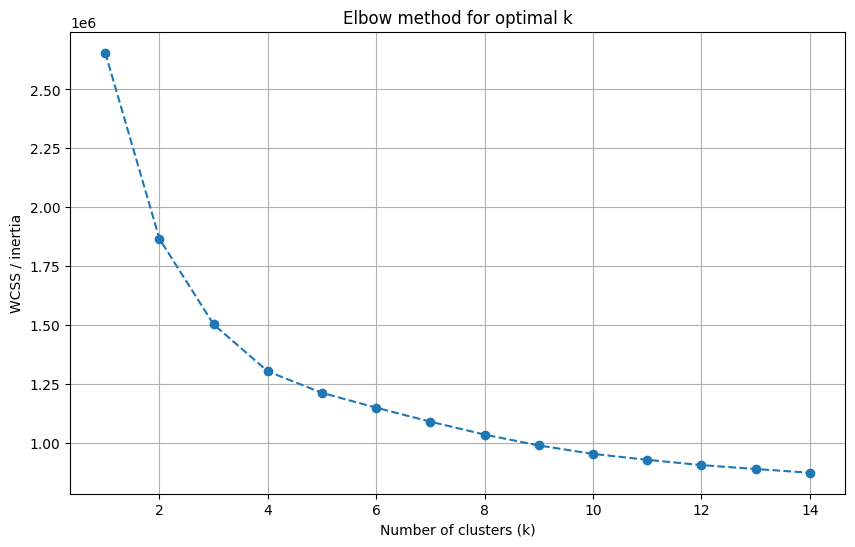

In [52]:
#Plotting the elbow curve
plt.figure(figsize=(10,6))
plt.plot(krange,wcss,marker="o",linestyle="--")
plt.title("Elbow method for optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS / inertia")
plt.grid(True)
plt.show()

From the above graph, the optimal value for k is 6.

In [53]:
#Performing kmeans clustering using the k value as 6 and assinging a cluster ID to each player in the dataframe.
kmeans=KMeans(n_clusters=6,init="k-means++",random_state=42,n_init=10)
cluster_assignments=kmeans.fit_predict(cluster_df)
scaled_df["cluster_id"]=cluster_assignments

In [54]:
df_with_cluster=scaled_df.copy()
centroid_df = pd.DataFrame(kmeans.cluster_centers_, columns=cluster_df.columns)
centroid_df['Cluster_ID'] = range(6)

In [55]:
#Performing euclidean distance to find the similar player
from sklearn.metrics.pairwise import euclidean_distances

if "cluster_id" not in scaled_df.columns:
  print("Error in clustering operation")

def player_recommendation(target_player_id,scaled_df,df,top_n):
  target_cluster=scaled_df.loc[scaled_df['player_id']==target_player_id,"cluster_id"].iloc[0]
  player_pool=scaled_df[
      (scaled_df['cluster_id']==target_cluster) &
      (scaled_df['player_id']!=target_player_id)
  ].copy()

  target_features=scaled_df[scaled_df['player_id']==target_player_id][cluster_df.columns].values
  player_features=player_pool[cluster_df.columns].values

  distance=euclidean_distances(target_features,player_features)[0]
  player_pool['similarity_score']=distance
  recommendation=player_pool.sort_values(by='similarity_score',ascending=True).head(top_n)

  output=pd.merge(
      recommendation[['player_id','similarity_score']],
      df[['player_id','player_name','player_positions','wage_eur','club_name']],
      on='player_id',
      how='left'
  )

  return output

In [56]:
#creating an input area where the user can select the player name from the dropdown list
import ipywidgets as widgets
from IPython.display import display, clear_output

player_name=sorted(df['player_name'].unique().tolist())
player_dropdown=widgets.Combobox(
    placeholder="Select a player",
    options=player_name,
    description="Player:",
    ensure_option=True,
    style={"description_width":"initial"},
    layout=widgets.Layout(width="50%"))

output_area=widgets.Output()

def on_player_select(change):
  with output_area:
    clear_output(wait=True)
    selected_name = change.new
    if selected_name and selected_name in player_name:
        target_player_id = df[df['player_name'] == selected_name]['player_id'].iloc[0]
        target_player_data = df[df['player_id'] == target_player_id]
        print("\nData for target player:")
        print(target_player_data[['player_name', 'player_positions', 'club_name']])
        recommendation=player_recommendation(target_player_id,scaled_df,df,5)
        print("\nData for recommended players:")
        print(recommendation[['player_name','player_positions','club_name','wage_eur']])
    elif selected_name:
        print("Please select a valid player name from the list.")

player_dropdown.observe(on_player_select, names='value')

print("--- Player Recommendation System Input ---")
display(player_dropdown, output_area)

--- Player Recommendation System Input ---


Combobox(value='', description='Player:', ensure_option=True, layout=Layout(width='50%'), options=('A. Zervand…

Output()